<a href="https://colab.research.google.com/github/IliyaCetoVoka/Car-Price-Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Car** **Price** **Prediction** **Analysis**

In [ ]:
# Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("/content/Car_data_jtrjuw.csv")
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


**Data** **Exploration** (EDA)**bold text**

### Checking for Missing Values

In [ ]:
print('Missing values in each column:')
print(data.isnull().sum())

Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


### Visualizing Relationships (Selling Price vs. Features)

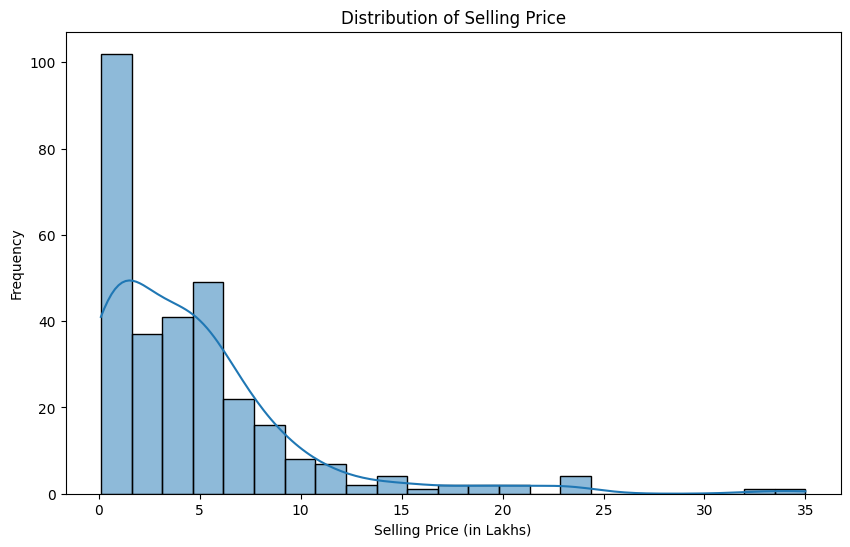

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Frequency')
plt.show()

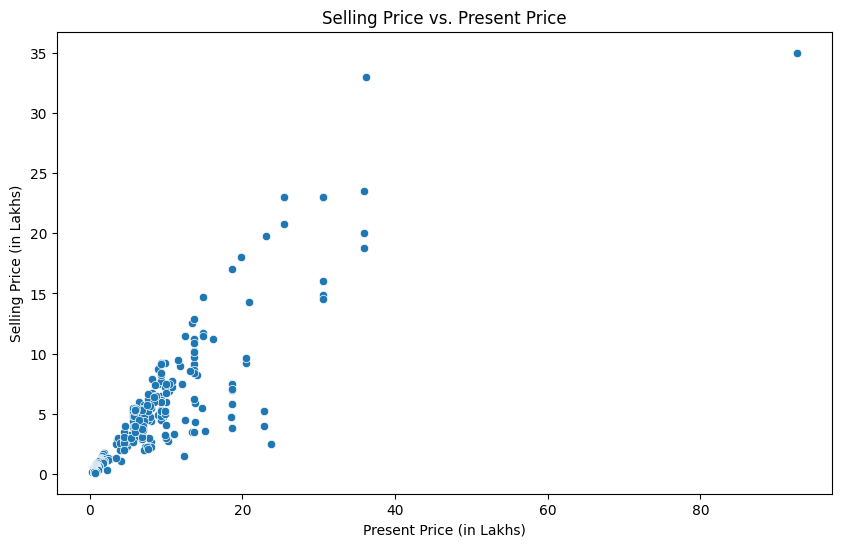

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=data)
plt.title('Selling Price vs. Present Price')
plt.xlabel('Present Price (in Lakhs)')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

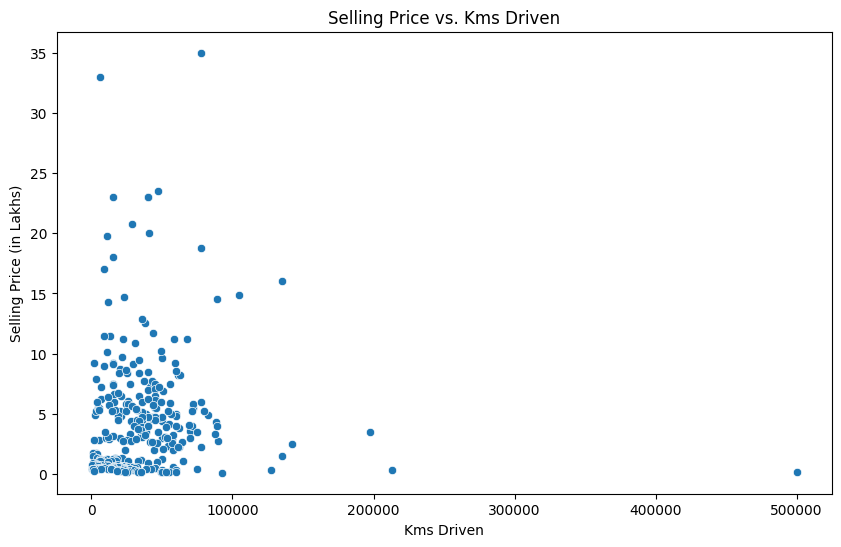

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=data)
plt.title('Selling Price vs. Kms Driven')
plt.xlabel('Kms Driven')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

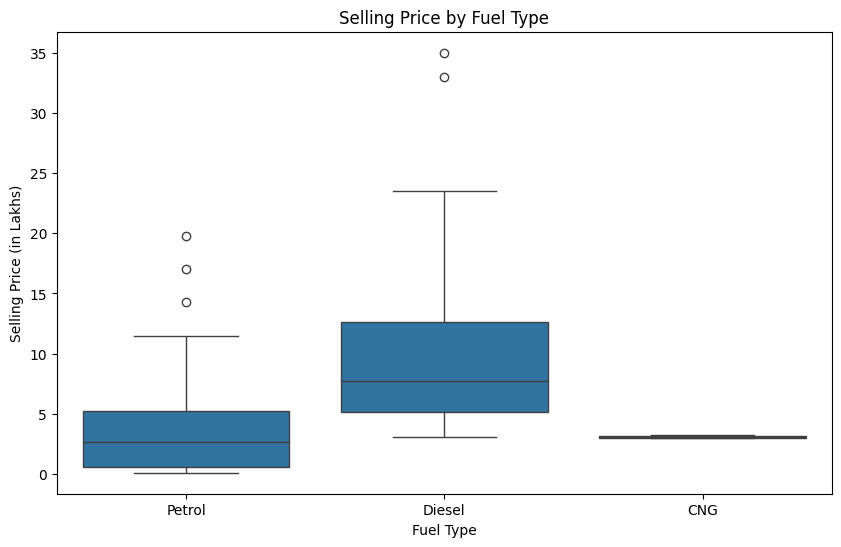

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=data)
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

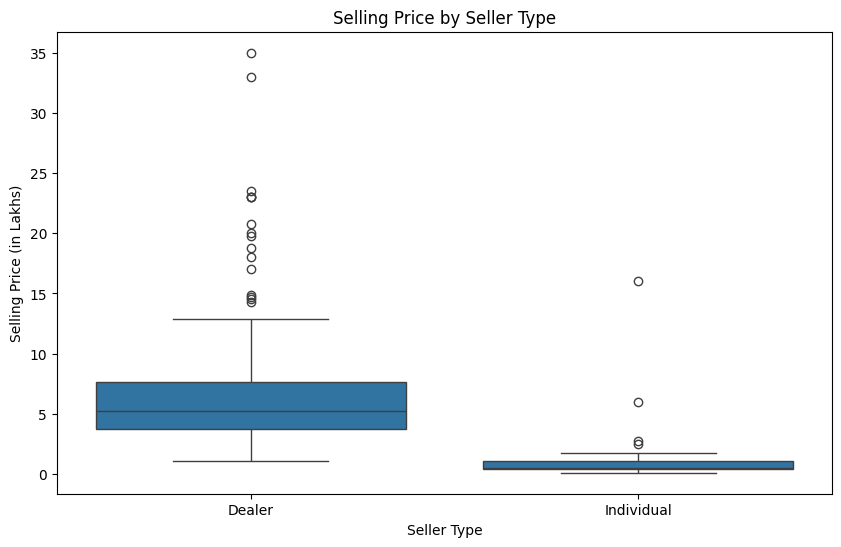

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Seller_Type', y='Selling_Price', data=data)
plt.title('Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

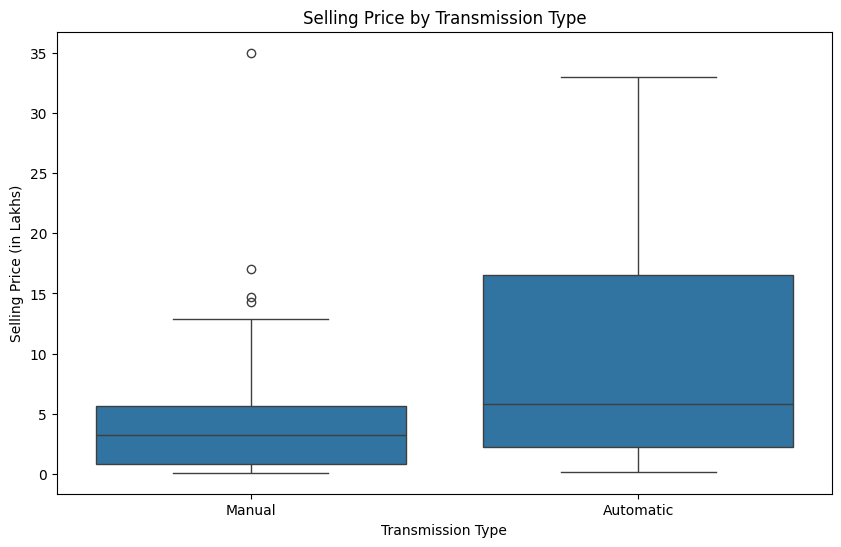

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Transmission', y='Selling_Price', data=data)
plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

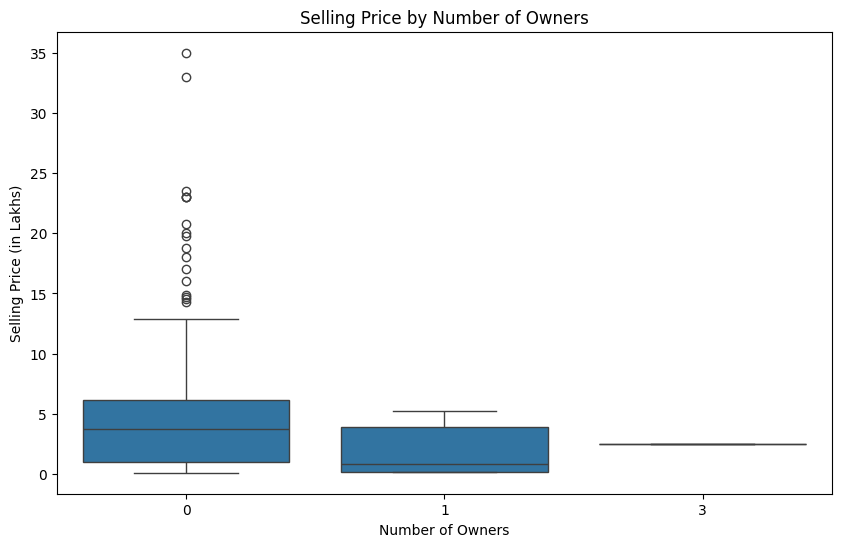

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Owner', y='Selling_Price', data=data)
plt.title('Selling Price by Number of Owners')
plt.xlabel('Number of Owners')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

Data Preprocessing Analysis

Encoding Categorical Data

In [ ]:
# Drop Car_Name column due to high cardinality
data = data.drop('Car_Name', axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

# Apply one-hot encoding
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

display(data_encoded.head())

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True


Features Scaling

In [ ]:
# Identify numerical columns for scaling (excluding the target variable 'Selling_Price')
numerical_cols = ['Year', 'Present_Price', 'Kms_Driven']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns
data_encoded[numerical_cols] = scaler.fit_transform(data_encoded[numerical_cols])

display(data_encoded.head())

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,0.128897,3.35,-0.236215,-0.256224,0,False,True,False,True
1,-0.217514,4.75,0.221505,0.155911,0,True,False,False,True
2,1.168129,7.25,0.257427,-0.773969,0,False,True,False,True
3,-0.910335,2.85,-0.403079,-0.817758,0,False,True,False,True
4,0.128897,4.60,-0.087890,0.141743,0,True,False,False,True


Model Building

In [ ]:
# Separate features (X) and target (y)
X = data_encoded.drop('Selling_Price', axis=1)
y = data_encoded['Selling_Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (240, 8)
X_test shape: (61, 8)
y_train shape: (240,)
y_test shape: (61,)


In [ ]:
# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


R-squared: 0.8490
Mean Absolute Error (MAE): 1.2162
Mean Squared Error (MSE): 3.4788
Root Mean Squared Error (RMSE): 1.8652


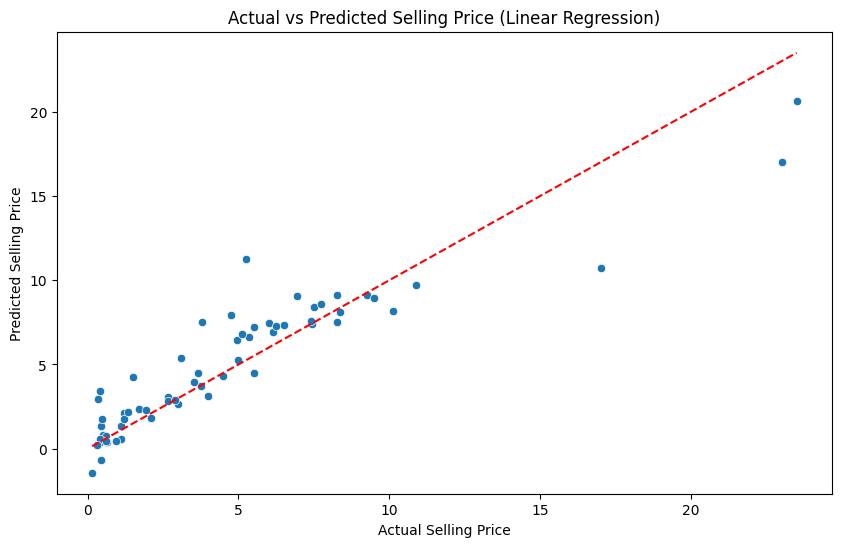

In [ ]:
# Make predictions on the test set
y_pred = linear_reg_model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price (Linear Regression)')
plt.show()

Prediction

### Predicting Selling Price for Sample Cars

In [ ]:
# Select 5 random sample cars from the original data (before encoding and scaling)
sample_cars_original = data.sample(n=5, random_state=42)

print("Original Sample Cars Data:")
display(sample_cars_original)


Original Sample Cars Data:


,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
177,2016,0.35,0.57,24000,Petrol,Individual,Automatic,0
289,2016,10.11,13.60,10980,Petrol,Dealer,Manual,0
228,2012,4.95,9.40,60000,Diesel,Dealer,Manual,0
198,2011,0.15,0.57,35000,Petrol,Individual,Manual,1
60,2013,6.95,18.61,40001,Petrol,Dealer,Manual,0


In [ ]:
# Preprocess the sample cars using the same steps as the training data

# sample_cars_original already doesn't have 'Car_Name' as it was dropped from the main 'data' dataframe
sample_cars_processed = sample_cars_original.copy() # Make a copy to avoid modifying original

# Keep a copy of selling price for comparison if needed, then drop it for prediction
sample_cars_actual_selling_price = sample_cars_processed['Selling_Price']
sample_cars_for_prediction = sample_cars_processed.drop('Selling_Price', axis=1)

# Apply one-hot encoding using the same categorical columns
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
sample_cars_encoded = pd.get_dummies(sample_cars_for_prediction, columns=categorical_cols, drop_first=True)

# Identify numerical columns for scaling
numerical_cols = ['Year', 'Present_Price', 'Kms_Driven']

# Ensure all columns from X_train are present in sample_cars_encoded and in the same order
# Add missing columns (if any) with default value 0
missing_cols = set(X_train.columns) - set(sample_cars_encoded.columns)
for c in missing_cols:
    sample_cars_encoded[c] = 0
# Ensure the order of columns is the same as X_train
sample_cars_encoded = sample_cars_encoded[X_train.columns]

# Apply scaling to numerical columns using the *fitted* scaler
sample_cars_encoded[numerical_cols] = scaler.transform(sample_cars_encoded[numerical_cols])

print("Processed Sample Cars Data (for prediction):")
display(sample_cars_encoded)


Processed Sample Cars Data (for prediction):


,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
177,0.821718,-0.817924,-0.333500,0,0,True,True,False
289,0.821718,0.691970,-0.668875,0,0,True,False,True
228,-0.563924,0.205282,0.593804,0,0,False,False,True
198,-0.910335,-0.817924,-0.050157,1,0,True,True,True
60,-0.217514,1.272521,0.078661,0,0,True,False,True
